# FitzHugh-Nagumo Bayesian Operator Inference (WITH PRIOR MEAN)

This notebook demonstrates the GP-Bayes OpInf method **with a deterministic prior mean** for fair comparison with the Full Bayesian method.

**Key Difference from 01_gpbayes_opinf.ipynb:**
- `use_prior=True`: Uses deterministic OpInf solution as the prior mean
- This makes the method more comparable to Full Bayesian OpInf which also uses a deterministic prior

**Configuration for Fair Comparison:**
- `RANDOM_SEED=42`: Ensures reproducible results (data noise, time sampling)
- `noiselevel=0.03`: Matches the SVI method
- `num_regression_points=num_samples*1`: Matches the SVI method

In [15]:
# Setup paths and imports
import sys
import os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('.')), '..'))

import numpy as np
import random
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation 
from IPython.display import HTML

import opinf

# Import from core and local config
from core import (
    summarize_experiment,
    generate_trajectory,
    fit_gaussian_processes,
    BayesianROM,
)
import config

In [24]:
# Configuration parameters
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# Experiment settings
training_span = (0, 3)
num_samples = 300
noiselevel = 0.01
num_regression_points = num_samples * 1
numPODmodes = 3
gp_regularizer = 1e8
ndraws = 100

# Update time domain in config
config.time_domain = np.linspace(0, 5, 801)

if isinstance(numPODmodes, (list, tuple)) and len(numPODmodes) == 1:
    numPODmodes = numPODmodes[0]

In [25]:
# Report experimental scenario
summarize_experiment(
    training_span=training_span,
    num_samples=num_samples,
    noiselevel=noiselevel,
    num_regression_points=num_regression_points,
    numPODmodes=numPODmodes,
    gp_regularizer=gp_regularizer,
    ndraws=ndraws,
    figures_path="figures",
)

# Generate training data
(
    model,
    time_domain,
    true_states,
    time_domain_sampled,
    snapshots_sampled,
) = generate_trajectory(config, training_span, num_samples, noiselevel)

print(f"time_domain: {time_domain.shape}, true_states: {true_states.shape}")
print(f"time_domain_sampled: {time_domain_sampled.shape}, snapshots_sampled: {snapshots_sampled.shape}")


EXPERIMENTAL SCENARIO
Data: 300 uniformly sampled snapshots over 0.00 ≤ t < 3.00 with 1.00% noise
Dimension: retaining 3 POD modes
Training: using 300 regression points
GP regularization: eta = 1.00e+08
Posterior: 100 draws

generating training data...done in 0.28 s.
time_domain: (801,), true_states: (1024, 801)
time_domain_sampled: (300,), snapshots_sampled: (1024, 300)


In [26]:
# Dimensionality reduction (POD).
with opinf.utils.TimedBlock(
    f"reducing noisy training states to {numPODmodes} dimensions"
):
    basis = config.Basis(num_vectors=numPODmodes)
    print(basis)
    print(f"Snapshot sampled shape: {snapshots_sampled.shape}")
    basis.fit(snapshots_sampled)
    # print(f"{}")
    snapshots_compressed = basis.compress(snapshots_sampled)
    full_states_compressed = basis.compress(true_states)
    print(full_states_compressed.shape)

reducing noisy training states to 3 dimensions...Basis
  full_state_dimension:    None
  reduced_state_dimension: None
  SVD solver: scipy.linalg.svd()
Snapshot sampled shape: (1024, 300)
(3, 801)
done in 0.12 s.


In [27]:
# Fit Gaussian process kernels to the compressed training data
time_domain_training = np.linspace(
    training_span[0],
    training_span[-1],
    num_regression_points,
)

gps = fit_gaussian_processes(
    time_domain_training=time_domain_training,
    time_domain_sampled=time_domain_sampled,
    snapshots_sampled=snapshots_compressed,
    gp_regularizer=gp_regularizer,
    constant_bounds=config.CONSTANT_VALUE_BOUNDS,
    length_scale_bounds=config.LENGTH_SCALE_BOUNDS,
    noise_level_bounds=config.NOISE_LEVEL_BOUNDS,
    n_restarts_optimizer=config.N_RESTARTS_OPTIMIZER,
)

q0 = snapshots_compressed[:, 0]


fitting GP model for state 'r_01'...
Gaussian radial basis function kernel
	k(t, t') = \sigma^2 exp(-(t - t')^2 / (2 \ell^2)) + \chi I
	\sigma^2 = 1.3057e+02
	\ell = 5.2850e-02
	\chi = 1.9574e-04
done in 17.86 s.
computing weight matrix...done in 0.17 s.

fitting GP model for state 'r_02'...
Gaussian radial basis function kernel
	k(t, t') = \sigma^2 exp(-(t - t')^2 / (2 \ell^2)) + \chi I
	\sigma^2 = 1.5981e+00
	\ell = 4.2560e-02
	\chi = 2.2595e-05
done in 17.55 s.
computing weight matrix...done in 0.15 s.

fitting GP model for state 'r_03'...
Gaussian radial basis function kernel
	k(t, t') = \sigma^2 exp(-(t - t')^2 / (2 \ell^2)) + \chi I
	\sigma^2 = 1.2258e+00
	\ell = 4.3799e-02
	\chi = 9.4670e-06
done in 17.58 s.
computing weight matrix...done in 0.16 s.


In [28]:
# Estimate posterior using GP-BayesOpInf WITH PRIOR MEAN
import step3_estimate as step3

# Create the posterior and fit it 
input_func = config.ReducedOrderModel.input_func
inputs = None if input_func is None else input_func(time_domain_training)

# Use deterministic OpInf solve as prior mean for fairer comparison with Full Bayesian
bayesian_model = step3.estimate_posterior(
    time_domain=np.array(time_domain),
    gps=gps,
    inputs=np.array(inputs),
    use_prior=True,  # <-- Use deterministic prior mean
    prior_regularizer=1e-4,  # Regularization for prior computation
)

constructing posterior hyperparameters...

GRIDSEARCH
(1/81) Testing regularizer 1.0000e-16...UNSTABLE
(2/81) Testing regularizer 1.7783e-16...UNSTABLE
(3/81) Testing regularizer 3.1623e-16...UNSTABLE
(4/81) Testing regularizer 5.6234e-16...UNSTABLE
(5/81) Testing regularizer 1.0000e-15...UNSTABLE
(6/81) Testing regularizer 1.7783e-15...UNSTABLE
(7/81) Testing regularizer 3.1623e-15...UNSTABLE
(8/81) Testing regularizer 5.6234e-15...UNSTABLE
(9/81) Testing regularizer 1.0000e-14...UNSTABLE
(10/81) Testing regularizer 1.7783e-14...UNSTABLE
(11/81) Testing regularizer 3.1623e-14...UNSTABLE
(12/81) Testing regularizer 5.6234e-14...UNSTABLE
(13/81) Testing regularizer 1.0000e-13...UNSTABLE
(14/81) Testing regularizer 1.7783e-13...UNSTABLE
(15/81) Testing regularizer 3.1623e-13...UNSTABLE
(16/81) Testing regularizer 5.6234e-13...UNSTABLE
(17/81) Testing regularizer 1.0000e-12...UNSTABLE
(18/81) Testing regularizer 1.7783e-12...UNSTABLE
(19/81) Testing regularizer 3.1623e-12...UNSTABLE
(20/8

In [29]:
# Draw samples from the posterior.

time_domain_eval_training = np.linspace(0, max(time_domain_sampled), num_regression_points)

with opinf.utils.TimedBlock("sampling posterior distribution"):
    draws_compressed_training = []
    draws_compressed = []
    qbar = snapshots_compressed.mean(axis=1).reshape((-1, 1))
    bound = 5 * np.max(np.abs(snapshots_compressed - qbar), axis=1)
    num_unstables = 0
    Os = []
    for _ in range(ndraws):
        draw = bayesian_model.predict(
            initial_conditions=q0,
            timepoints=time_domain,
            input_func=input_func,
        )
        training_draw = bayesian_model.predict(
            initial_conditions=q0,
            timepoints=time_domain_eval_training,
            input_func=input_func,
        )
        Os.append(bayesian_model.rvs())
        if draw.shape[1] != time_domain.size or training_draw.shape[1] != time_domain_training.size:
            num_unstables += 1
            continue
        if np.any(np.abs(draw - qbar).max(axis=1) > bound):
            num_unstables += 1
            continue
        draws_compressed_training.append(training_draw)
        draws_compressed.append(draw)
    if num_unstables:
        print(f"\n{num_unstables}/{ndraws} draws unstable")

    # Translate results back to original state space.
    draws = [basis.decompress(draw) for draw in draws_compressed]
    Os = np.array(Os)

sampling posterior distribution...done in 8.08 s.


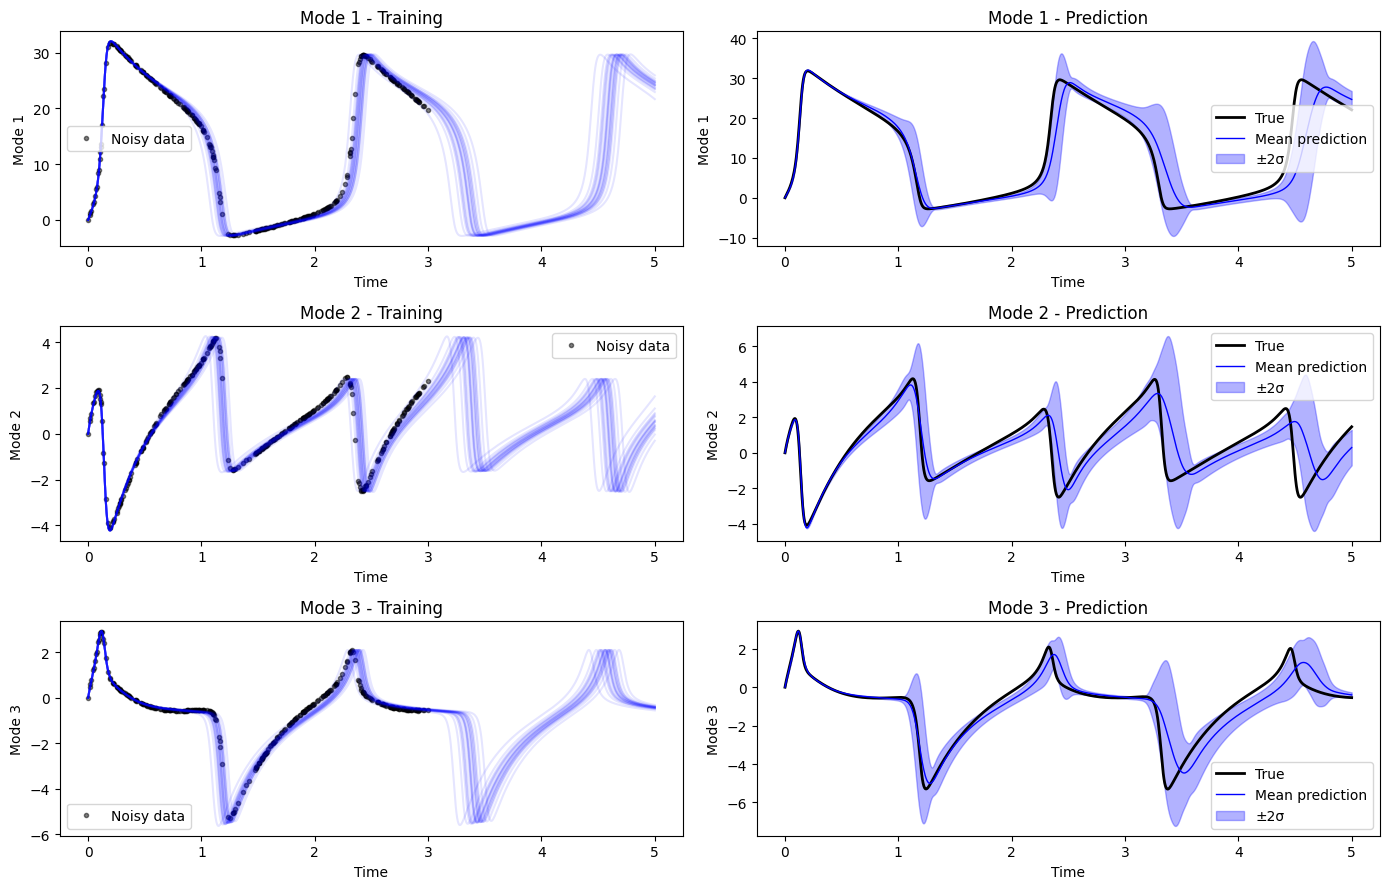


Number of stable draws: 100/100


In [30]:
# Visualize results
fig, axes = plt.subplots(numPODmodes, 2, figsize=(14, 3*numPODmodes))

for i in range(numPODmodes):
    # Training region
    ax = axes[i, 0]
    ax.plot(time_domain_sampled, snapshots_compressed[i], 'ko', ms=3, alpha=0.5, label='Noisy data')
    for draw in draws_compressed[:20]:
        ax.plot(time_domain, draw[i], 'b-', alpha=0.1)
    ax.set_xlabel('Time')
    ax.set_ylabel(f'Mode {i+1}')
    ax.set_title(f'Mode {i+1} - Training')
    ax.legend()
    
    # Full prediction
    ax = axes[i, 1]
    ax.plot(time_domain, full_states_compressed[i], 'k-', lw=2, label='True')
    draws_mean = np.mean([d[i] for d in draws_compressed], axis=0)
    draws_std = np.std([d[i] for d in draws_compressed], axis=0)
    ax.plot(time_domain, draws_mean, 'b-', lw=1, label='Mean prediction')
    ax.fill_between(time_domain, draws_mean - 2*draws_std, draws_mean + 2*draws_std, 
                    alpha=0.3, color='blue', label='±2σ')
    ax.set_xlabel('Time')
    ax.set_ylabel(f'Mode {i+1}')
    ax.set_title(f'Mode {i+1} - Prediction')
    ax.legend()

plt.tight_layout()
plt.savefig('figures/gpbayes_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nNumber of stable draws: {len(draws_compressed)}/{ndraws}")